### Random Forest for Drought Prediciton in Pueblo County, Colorado

 I will go retake the code of the last notebook, but this time I will apply the Random Forest method, so I will not delve too much into redundancies.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import plot_tree

# Reading the dataset
df = pd.read_parquet('final_dataset_pueblo.parquet')

# Replacing NaN values with 0
df = df.fillna(0)

# Features and target list

features = ['precip', 'max_temp', 'min_temp', 'gwl', 'daily_discharge_cfs','sm_pca', 'st_pca']
target = 'target'

# Splitting up into training and testing tests for the feature sets and target sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size = 0.2, random_state = 0)

# Scaling the features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)

display(pd.DataFrame(X_train).head())



,0,1,2,3,4,5,6
0,-0.236413,-0.703677,-1.472493,-0.789317,-0.043247,0.398965,-1.188105
1,0.574686,-1.801402,-1.034528,-1.157828,-0.211894,-0.693305,0.026048
2,0.353477,-1.551919,-0.706055,-2.079106,-0.125433,-0.094971,1.070523
3,-0.236413,-1.502023,-1.636730,0.845953,-0.201374,0.034684,1.025768
4,-0.236413,-0.454194,-0.322836,1.813295,-0.026809,0.728431,-0.721967


As mentioned, this time I'm going to use RandomForestClassifier instead.

Text(0.5, 1.0, 'Confusion Matrix for Random Forest Classifier')

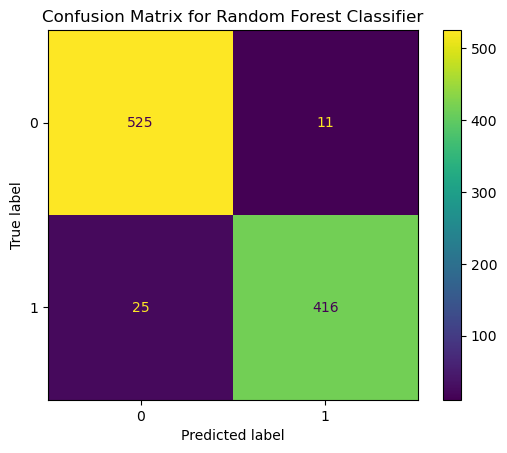

In [3]:
classifier = RandomForestClassifier(random_state = 0).fit(X_train, y_train)
preds = classifier.predict(sc.transform(X_test))

# Generating the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Random Forest Classifier')

In [4]:
# Accuracy, F1 Score and Recall Score

accuracy = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)
recall = recall_score(y_test, preds)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Recall Score: {recall}')

Accuracy: 0.9631525076765609
F1 Score: 0.9585253456221198
Recall Score: 0.9433106575963719


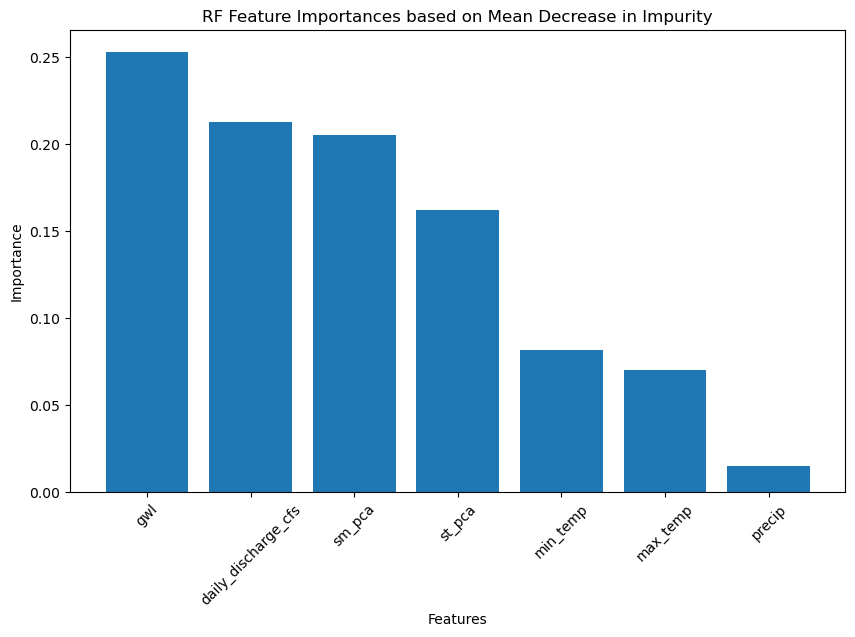

In [5]:
# Visualizing the feature importance

importances = classifier.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("RF Feature Importances based on Mean Decrease in Impurity")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

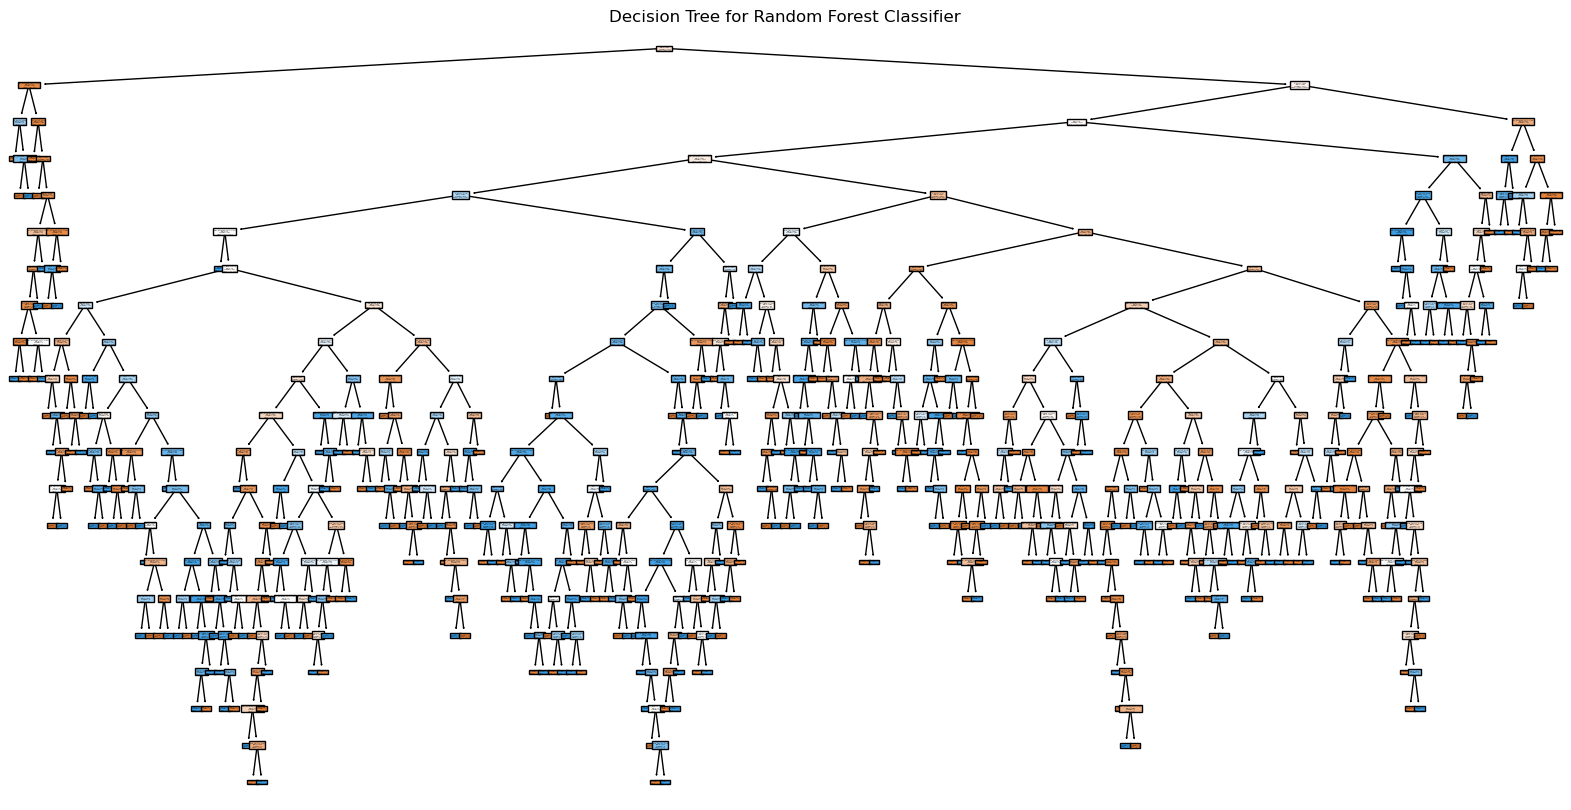

In [6]:
# Visualizing the decision tree for Random Forest Classifier

plt.figure(figsize=(20, 10))
plot_tree(classifier.estimators_[0], feature_names=features, filled=True)
plt.title('Decision Tree for Random Forest Classifier')
plt.show()